In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('E:\Gen Ai Course\Projects\ML Project\product-review-intelligence\Reviews.csv')

<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:1: SyntaxWarning: invalid escape sequence '\G'
C:\Users\hp\AppData\Local\Temp\ipykernel_508352\3072456770.py:1: SyntaxWarning: invalid escape sequence '\G'
  df = pd.read_csv('E:\Gen Ai Course\Projects\ML Project\product-review-intelligence\Reviews.csv')


In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df.shape

(568454, 10)

In [ ]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')

In [ ]:
df = df[['ProductId','Score','Summary','Text']].copy()

In [ ]:
df.head()

,ProductId,Score,Summary,Text
0,B001E4KFG0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,B00813GRG4,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,B000LQOCH0,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,B000UA0QIQ,2,Cough Medicine,If you are looking for the secret ingredient i...
4,B006K2ZZ7K,5,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df.isnull().sum()

ProductId     0
Score         0
Summary      27
Text          0
dtype: int64

In [ ]:
df = df.dropna(subset=['Summary'])

In [ ]:
df.shape

(568427, 4)

In [ ]:
def rating_to_sentiment(score):
    if score <=2:
        return 0
    elif score == 3:
        return 1
    else:
        return 2

In [ ]:
df['label'] = df['Score'].apply(rating_to_sentiment)

In [ ]:
label_names = {
    0: 'Negative',
    1: 'Neutral',
    2: 'Positive'
}

df["Sentiment"] = df['label'].map(label_names)

In [ ]:
df[['Score','Sentiment']].head(20)

,Score,Sentiment
0,5,Positive
1,1,Negative
2,4,Positive
3,2,Negative
4,5,Positive
5,4,Positive
6,5,Positive
7,5,Positive
8,5,Positive
9,5,Positive


In [ ]:
df['Summary'] = df['Summary'].fillna('')

df['review'] = (df['Summary'].astype(str) + '. ' + df['Text'].astype(str))

In [ ]:
df[['review', 'Sentiment']].head()

,review,Sentiment
0,Good Quality Dog Food. I have bought several o...,Positive
1,Not as Advertised. Product arrived labeled as ...,Negative
2,"""Delight"" says it all. This is a confection th...",Positive
3,Cough Medicine. If you are looking for the sec...,Negative
4,Great taffy. Great taffy at a great price. Th...,Positive


In [ ]:
print("Before:", len(df))

df = df.drop_duplicates(subset=['review'])

print("After:", len(df))

Before: 568427
After: 394967


In [ ]:
sentiment_counts = df['Sentiment'].value_counts()

In [ ]:
sentiment_counts

Sentiment
Positive    307787
Negative     57345
Neutral      29835
Name: count, dtype: int64

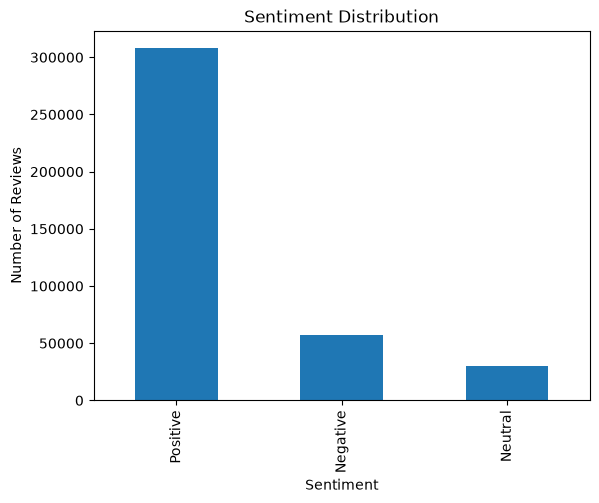

In [ ]:
sentiment_counts.plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
positive = df[df['label'] == 2].sample(n=20000, random_state=42)
negative = df[df['label'] == 0].sample(n=20000, random_state=42)
neutral = df[df['label'] == 1].sample(n=10000, random_state=42)

In [ ]:
balanced_df = pd.concat([positive, negative, neutral])

In [ ]:
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
balanced_df.shape

(50000, 7)

In [ ]:
balanced_df[['review','label','Sentiment']].to_csv('../data/processed/reviews_50k.csv', index=False)

In [ ]:
train_df, temp_df = train_test_split(balanced_df, test_size=0.20, stratify=balanced_df['label'], random_state=42)

In [ ]:
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

In [ ]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 40000
Validation: 5000
Test: 5000


In [ ]:
train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/validation.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

In [ ]:
import re

In [ ]:
def clean_text(text):
    text = str(text)
    
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [ ]:
balanced_df['review'] = balanced_df['review'].apply(clean_text)